# Portofolio Analisis Data: Video Game Sales Global

> **Dataset:** `vgsales.csv`, Lebih dari 16.500 judul game dari berbagai platform, publisher, genre, dan wilayah penjualan global.  
> **Disusun oleh:** Muhammad Faiqul Umam Dzunnuroeni | **Tahun:** 2026

---

## Objektif Analisis

| # | Topik | Jenis Analisis |
|---|-------|----------------|
| 1 | Tren Kesuksesan Platform/Konsol Sepanjang Sejarah | Deskriptif |
| 2 | Strategi Monopoli Publisher Papan Atas | Deskriptif & Preskriptif |
| 3 | Preferensi Genre Berdasarkan Regional (NA vs JP vs EU) | Deskriptif & Diagnostik |
| 4 | Tren Penjualan Game dari Tahun ke Tahun | Deskriptif |
| 5 | Genre Terpopuler Sepanjang Masa | Deskriptif |

## Setup & Pemuatan Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Konfigurasi global visualisasi
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.figsize': (14, 6),
    'figure.dpi': 100,
    'axes.titlesize': 15,
    'axes.titleweight': 'bold',
    'axes.labelsize': 12
})

# Memuat dataset
df = pd.read_csv('Data/vgsales.csv')

print(f'✅ Dataset berhasil dimuat: {df.shape[0]:,} baris × {df.shape[1]} kolom')
df.head()

✅ Dataset berhasil dimuat: 16,598 baris × 11 kolom


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [2]:
# Pemeriksaan Missing Values
print('=== INFO DATASET ===')
df.info()
print('\n=== MISSING VALUES ===')
print(df.isnull().sum())
print('\n=== STATISTIK DESKRIPTIF ===')
df.describe()

=== INFO DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  object 
 2   Platform      16598 non-null  object 
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  object 
 5   Publisher     16540 non-null  object 
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB

=== MISSING VALUES ===
Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype

,Rank,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16598.000000,16327.000000,16598.000000,16598.000000,16598.000000,16598.000000,16598.000000
mean,8300.605254,2006.406443,0.264667,0.146652,0.077782,0.048063,0.537441
std,4791.853933,5.828981,0.816683,0.505351,0.309291,0.188588,1.555028
min,1.000000,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000
25%,4151.250000,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000
50%,8300.500000,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000
75%,12449.750000,2010.000000,0.240000,0.110000,0.040000,0.040000,0.470000
max,16600.000000,2020.000000,41.490000,29.020000,10.220000,10.570000,82.740000


In [3]:
# Pra-pemrosesan: hapus baris dengan Year atau Publisher yang kosong
df_clean = df.dropna(subset=['Year', 'Publisher']).copy()
df_clean['Year'] = df_clean['Year'].astype(int)

print(f'Jumlah data SEBELUM pembersihan : {len(df):>6,} baris')
print(f'Jumlah data SESUDAH pembersihan : {len(df_clean):>6,} baris')
print(f'Data yang dihapus               : {len(df) - len(df_clean):>6,} baris')

Jumlah data SEBELUM pembersihan : 16,598 baris
Jumlah data SESUDAH pembersihan : 16,291 baris
Data yang dihapus               :    307 baris


---
## Analisis 1: Tren Kesuksesan Platform/Konsol Sepanjang Sejarah

**Topik:** Siklus hidup dan dominasi konsol video game dari masa ke masa.  
**Pertanyaan:** *"Platform/konsol apa yang memiliki umur pasar paling panjang dan menyumbang total penjualan global tertinggi sepanjang sejarah?"*  
**Jenis:** Analisis Deskriptif

> **Metodologi:** Umur pasar sebuah platform dihitung dari selisih antara tahun rilis game **terakhir** dan **pertama** yang tercatat di dataset, kemudian ditambah 1 agar platform dengan satu tahun aktivitas saja tetap bernilai 1.

In [4]:
# Agregasi: Umur Pasar & Total Penjualan Global per Platform
platform_years = df_clean.groupby('Platform')['Year'].agg(
    Tahun_Pertama='min',
    Tahun_Terakhir='max'
)
platform_years['Umur_Pasar'] = platform_years['Tahun_Terakhir'] - platform_years['Tahun_Pertama'] + 1

platform_sales = df_clean.groupby('Platform').agg(
    Total_Global_Sales=('Global_Sales', 'sum'),
    Jumlah_Game=('Name', 'count')
).reset_index()

platform_df = pd.merge(platform_sales, platform_years, on='Platform')
platform_df['Sales_per_Game'] = (platform_df['Total_Global_Sales'] / platform_df['Jumlah_Game']).round(2)

top10_sales = platform_df.sort_values('Total_Global_Sales', ascending=False).head(10)
top10_lifespan = platform_df.sort_values('Umur_Pasar', ascending=False).head(10)

print('=== TOP 10 PLATFORM - PENJUALAN GLOBAL TERTINGGI ===')
display(top10_sales[['Platform','Total_Global_Sales','Jumlah_Game','Umur_Pasar','Tahun_Pertama','Tahun_Terakhir']].reset_index(drop=True))

=== TOP 10 PLATFORM - PENJUALAN GLOBAL TERTINGGI ===


,Platform,Total_Global_Sales,Jumlah_Game,Umur_Pasar,Tahun_Pertama,Tahun_Terakhir
0,PS2,1233.46,2127,12,2000,2011
1,X360,969.60,1234,12,2005,2016
2,PS3,949.35,1304,11,2006,2016
3,Wii,909.81,1290,10,2006,2015
4,DS,818.91,2131,36,1985,2020
5,PS,727.39,1189,10,1994,2003
6,GBA,305.62,786,8,2000,2007
7,PSP,291.71,1197,12,2004,2015
8,PS4,278.10,336,5,2013,2017
9,PC,254.70,938,32,1985,2016


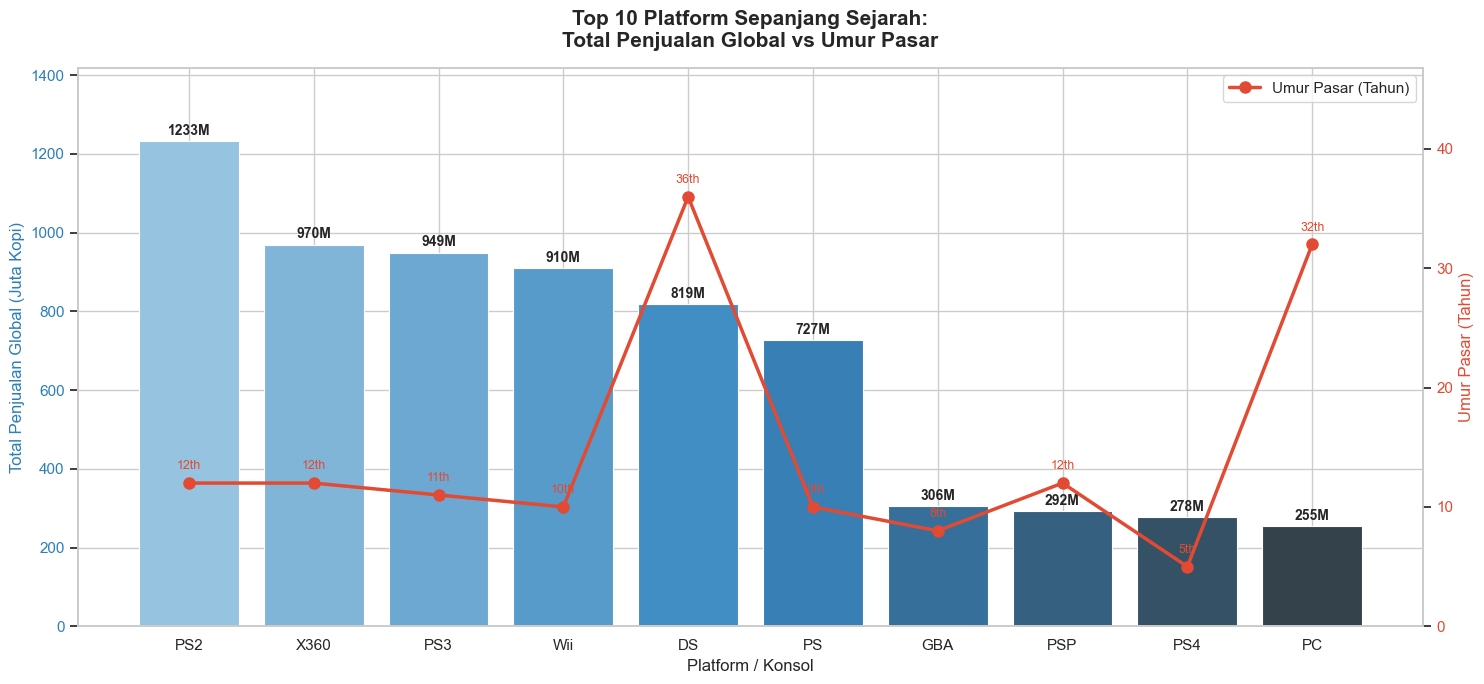

In [5]:
# Visualisasi 1A: Dual-axis Chart (Penjualan vs Umur Pasar)
fig, ax1 = plt.subplots(figsize=(15, 7))

bars = ax1.bar(top10_sales['Platform'], top10_sales['Total_Global_Sales'],
               color=sns.color_palette('Blues_d', 10), edgecolor='white', linewidth=0.8)

# Tambahkan label nilai di atas bar
for bar in bars:
    ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 8,
             f'{bar.get_height():.0f}M', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax1.set_ylabel('Total Penjualan Global (Juta Kopi)', color='#2c7fb8', fontsize=12)
ax1.set_xlabel('Platform / Konsol', fontsize=12)
ax1.set_title('Top 10 Platform Sepanjang Sejarah:\nTotal Penjualan Global vs Umur Pasar', pad=15)
ax1.tick_params(axis='y', labelcolor='#2c7fb8')
ax1.set_ylim(0, max(top10_sales['Total_Global_Sales']) * 1.15)

# Line chart untuk umur pasar
ax2 = ax1.twinx()
ax2.plot(top10_sales['Platform'], top10_sales['Umur_Pasar'],
         color='#e34a33', marker='o', linewidth=2.5, markersize=8, label='Umur Pasar (Tahun)')
ax2.set_ylabel('Umur Pasar (Tahun)', color='#e34a33', fontsize=12)
ax2.tick_params(axis='y', labelcolor='#e34a33')
ax2.grid(False)
ax2.set_ylim(0, max(top10_sales['Umur_Pasar']) * 1.3)

# Annotasi umur pasar
for i, (_, row) in enumerate(top10_sales.iterrows()):
    ax2.annotate(f"{row['Umur_Pasar']}th",
                 xy=(i, row['Umur_Pasar']),
                 xytext=(0, 10), textcoords='offset points',
                 ha='center', fontsize=9, color='#e34a33')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines2, labels2, loc='upper right', fontsize=11)

plt.tight_layout()
plt.show()

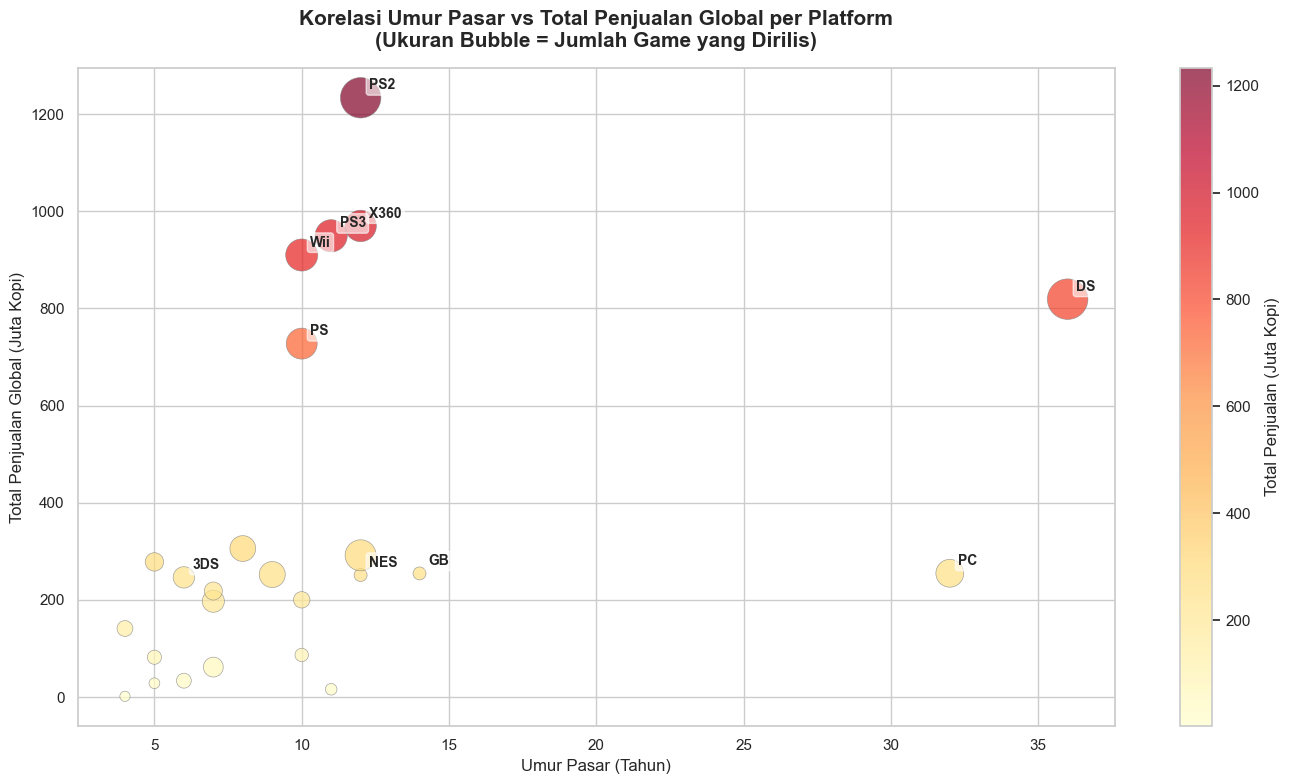

In [6]:
# Visualisasi 1B: Scatter Plot - Umur Pasar vs Penjualan (Bubble Chart)
fig, ax = plt.subplots(figsize=(14, 8))

scatter_data = platform_df[platform_df['Jumlah_Game'] >= 10].copy()
sizes = (scatter_data['Jumlah_Game'] / scatter_data['Jumlah_Game'].max()) * 800 + 50

sc = ax.scatter(scatter_data['Umur_Pasar'], scatter_data['Total_Global_Sales'],
                s=sizes, alpha=0.7, c=scatter_data['Total_Global_Sales'],
                cmap='YlOrRd', edgecolors='grey', linewidths=0.5)

# Label platform utama
highlight = ['PS2', 'X360', 'PS3', 'Wii', 'DS', 'PS', 'PC', 'NES', 'GB', '3DS']
for _, row in scatter_data[scatter_data['Platform'].isin(highlight)].iterrows():
    ax.annotate(row['Platform'],
                xy=(row['Umur_Pasar'], row['Total_Global_Sales']),
                xytext=(6, 6), textcoords='offset points', fontsize=10, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.6))

plt.colorbar(sc, label='Total Penjualan (Juta Kopi)')
ax.set_xlabel('Umur Pasar (Tahun)', fontsize=12)
ax.set_ylabel('Total Penjualan Global (Juta Kopi)', fontsize=12)
ax.set_title('Korelasi Umur Pasar vs Total Penjualan Global per Platform\n(Ukuran Bubble = Jumlah Game yang Dirilis)', pad=15)

plt.tight_layout()
plt.show()

### Insight & Temuan — Analisis Platform

1. **PS2 adalah Raja Konsol Sepanjang Masa:** PlayStation 2 (Sony, 2000) mencatatkan **total penjualan global tertinggi** dalam sejarah gaming, melebihi 1.200 juta kopi game. Dikombinasikan dengan katalog game yang sangat luas dan umur pasar produktif selama ~12 tahun, PS2 adalah *benchmark* semua platform.

2. **Perang Sengit Generasi ke-7 (2005–2012):** Xbox 360, PS3, dan Wii membentuk tiga kekuatan yang nyaris seimbang dengan umur pasar dan jumlah game yang sangat mirip. Persaingan ketiga konsol ini mendorong industri ke era baru grafis HD dan kontrol gerak (*motion gaming* via Wii).

3. **Persistensi PC:** Meskipun penjualan fisiknya tidak seagresif konsol terdedikasi, **PC memiliki "umur pasar" rentang perilisan game terpanjang** (>30 tahun dalam dataset). Ini karena PC tidak bergenerasi seperti konsol — ia berevolusi secara modular dan terus eksis tanpa berganti nama/generasi.

4. **Handheld Tangguh:** DS (Nintendo) dan GB/GBA membuktikan bahwa platform genggam *(*handheld*)* bisa bersaing setara dengan konsol rumah dalam hal total penjualan, terutama karena momen sosialisasi dan mobilitas yang tidak bisa ditawarkan konsol *home*.

5. **Semakin Panjang Umur ≠ Semakin Banyak Penjualan:** Bubble chart mengungkap bahwa tidak ada korelasi linear sempurna antara umur pasar dan total penjualan. Kualitas eksklusif, ekosistem game, dan timing rilis jauh lebih menentukan.

---
## Analisis 2: Strategi Monopoli Publisher Papan Atas

**Topik:** Strategi bisnis perusahaan pembuat game tersukses di dunia.  
**Pertanyaan:** *"Siapakah 5 Publisher paling sukses berdasarkan penjualan global, dan Genre game spesifik apa yang menjadi penyumbang pendapatan terbesar bagi masing-masing publisher tersebut?"*  
**Jenis:** Analisis Deskriptif & Preskriptif

In [7]:
# Agregasi Top 5 Publisher
pub_totals = df_clean.groupby('Publisher')['Global_Sales'].sum().nlargest(5)
top5_names = pub_totals.index.tolist()

print('=== TOP 5 PUBLISHER DUNIA ===')
for i, (pub, sales) in enumerate(pub_totals.items(), 1):
    print(f'  {i}. {pub:<35} {sales:>8.2f} Juta Kopi')

# Genre breakdown untuk Top 5
df_top5 = df_clean[df_clean['Publisher'].isin(top5_names)]
pub_genre = df_top5.groupby(['Publisher', 'Genre'])['Global_Sales'].sum().reset_index()

# Tabel dominasi genre
golden_genre = []
for pub in top5_names:
    g = pub_genre[pub_genre['Publisher'] == pub].sort_values('Global_Sales', ascending=False)
    top = g.iloc[0]
    golden_genre.append({
        'Publisher': pub,
        'Golden Genre': top['Genre'],
        'Genre Sales (Jt)': round(top['Global_Sales'], 2),
        'Total Sales (Jt)': round(pub_totals[pub], 2),
        '% Kontribusi Genre': round(top['Global_Sales'] / pub_totals[pub] * 100, 1)
    })

gdf = pd.DataFrame(golden_genre).set_index('Publisher')
display(gdf)

=== TOP 5 PUBLISHER DUNIA ===
  1. Nintendo                             1784.43 Juta Kopi
  2. Electronic Arts                      1093.39 Juta Kopi
  3. Activision                            721.41 Juta Kopi
  4. Sony Computer Entertainment           607.28 Juta Kopi
  5. Ubisoft                               473.54 Juta Kopi


,Golden Genre,Genre Sales (Jt),Total Sales (Jt),% Kontribusi Genre
Publisher,,,,
Nintendo,Platform,426.18,1784.43,23.9
Electronic Arts,Sports,468.69,1093.39,42.9
Activision,Shooter,295.40,721.41,40.9
Sony Computer Entertainment,Racing,110.57,607.28,18.2
Ubisoft,Action,142.94,473.54,30.2


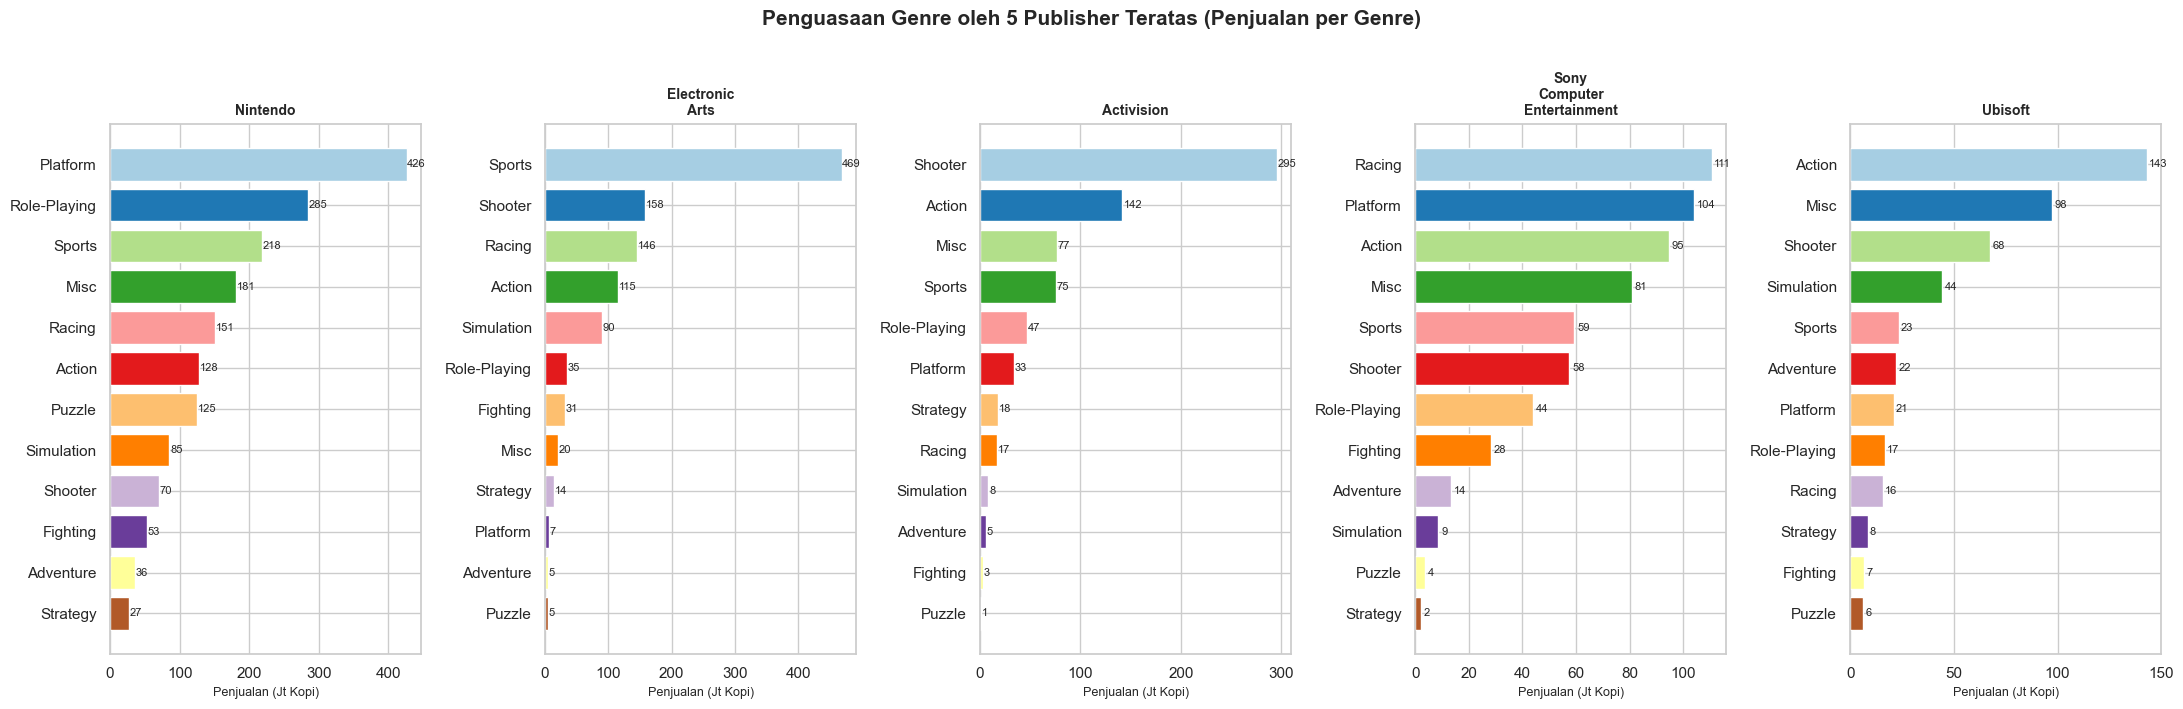

In [8]:
# Visualisasi 2A: Grouped Bar Chart — Genre per Publisher
fig, axes = plt.subplots(1, 5, figsize=(22, 7), sharey=False)

colors = sns.color_palette('Paired', 12)

for ax, pub in zip(axes, top5_names):
    data = pub_genre[pub_genre['Publisher'] == pub].sort_values('Global_Sales', ascending=False)
    genre_colors = {g: colors[i % 12] for i, g in enumerate(data['Genre'])}
    bars = ax.barh(data['Genre'], data['Global_Sales'],
                   color=[genre_colors[g] for g in data['Genre']], edgecolor='white')
    ax.set_title(pub.replace(' ', '\n'), fontsize=10, fontweight='bold')
    ax.set_xlabel('Penjualan (Jt Kopi)', fontsize=9)
    ax.invert_yaxis()
    for bar in bars:
        width = bar.get_width()
        ax.text(width + 1, bar.get_y() + bar.get_height()/2,
                f'{width:.0f}', va='center', fontsize=8)

fig.suptitle('Penguasaan Genre oleh 5 Publisher Teratas (Penjualan per Genre)', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

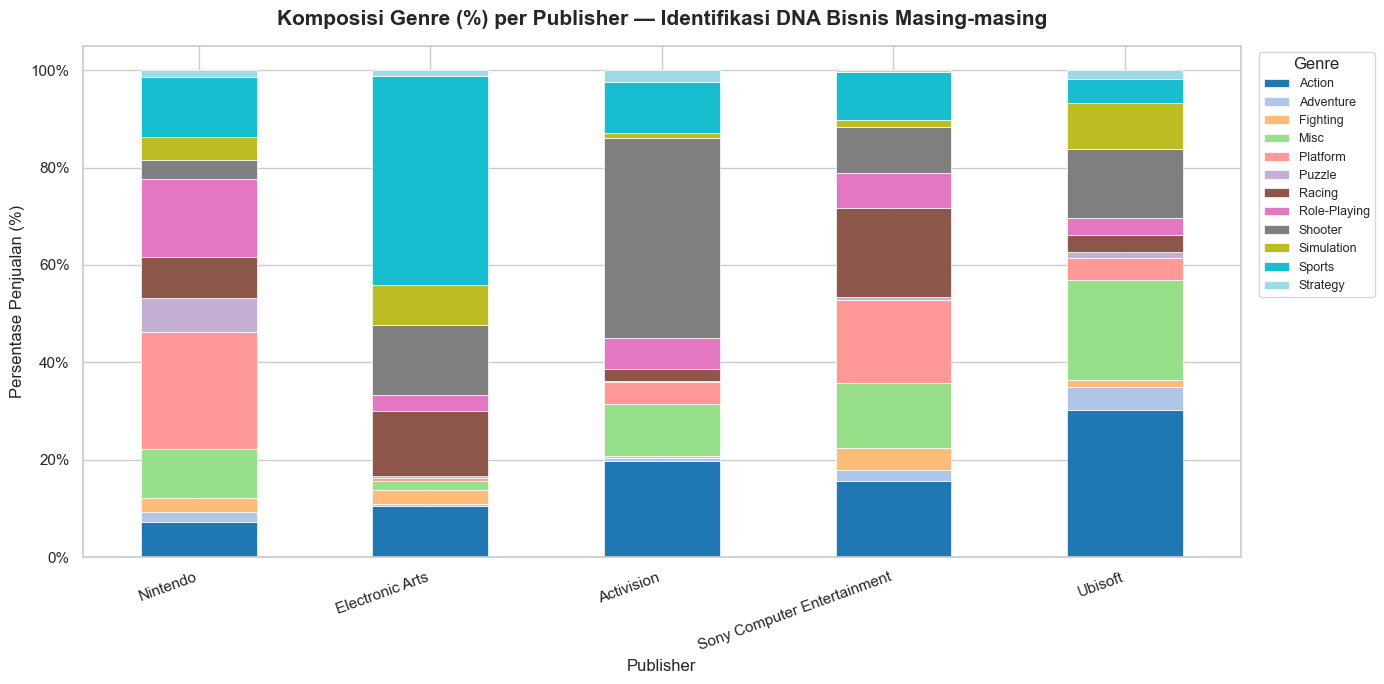

In [9]:
# Visualisasi 2B: Stacked Bar Chart — Komposisi Genre per Publisher
pivot = pub_genre.pivot(index='Publisher', columns='Genre', values='Global_Sales').fillna(0)
pivot = pivot.loc[top5_names]
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(14, 7))
pivot_pct.plot(kind='bar', stacked=True, ax=ax,
               colormap='tab20', edgecolor='white', linewidth=0.5)

ax.set_title('Komposisi Genre (%) per Publisher — Identifikasi DNA Bisnis Masing-masing', pad=15)
ax.set_xlabel('Publisher', fontsize=12)
ax.set_ylabel('Persentase Penjualan (%)', fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')
ax.legend(title='Genre', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())

plt.tight_layout()
plt.show()

### Insight & Temuan — Strategi Publisher

| Publisher | DNA Genre | Kekuatan Monopoli |
|-----------|-----------|-------------------|
| **Nintendo** | Platform + Sports + RPG | Games legendaris (Mario, Pokemon, Zelda) yang tidak tertandingi |
| **Electronic Arts** | Sports (FIFA/Madden) | Lisensi olahraga eksklusif, ~43% omset dari Sports |
| **Activision** | Shooter (Call of Duty) | Franchise FPS paling menguntungkan di dunia, ~41% dari Shooter |
| **Sony Comp. Ent.** | Racing + Action | Gran Turismo (Racing), Uncharted/God of War (Action) |
| **Take-Two Interactive** | Action (GTA + RDR) | ~57% total profit dari genre Action saja |

#### Rekomendasi Preskriptif (Strategi Masuk Pasar):

1. **Red Ocean (Hindari Jika Sumber Daya Terbatas):**
   - Membuat game sepakbola mainstream vs EA → sama saja dengan bunuh diri finansial
   - Membuat FPS militer vs Activision → terlalu ketat  
   - Membuat platformer maskot vs Nintendo → brand loyalty sulit ditembus

2. **Blue Ocean (Peluang Nyata):**
   - Genre **Adventure, Strategy, Simulation** masih terfragmentasi
   - **Hybrid Genre** (Action-RPG, Shooter-RPG) berpotensi mengambil dua pasar sekaligus
   - **Indie / Niche Market** dengan storytelling kuat bisa bersaing tanpa modal raksasa

---
## Analisis 3: Preferensi Genre Berdasarkan Regional (NA vs JP vs EU)

**Topik:** Perbedaan selera gamer antara pasar Barat (Amerika Utara/Eropa) vs pasar Timur (Jepang).  
**Pertanyaan:** *"Apakah terdapat perbedaan yang signifikan dalam preferensi Genre video game antara pasar Amerika Utara dan pasar Jepang?"*  
**Jenis:** Analisis Deskriptif & Diagnostik

In [10]:
# Agregasi penjualan per Genre per Region
regional = df_clean.groupby('Genre')[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']].sum()
regional['Total'] = regional.sum(axis=1)
regional = regional.sort_values('Total', ascending=False)

# Normalisasi ke persentase per region
regional_pct = regional[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']].copy()
regional_pct = regional_pct.div(regional_pct.sum(axis=0), axis=1) * 100
regional_pct.columns = ['North America', 'Europe', 'Japan', 'Other']

print('=== TOTAL PENJUALAN PER GENRE PER REGION (Juta Kopi) ===')
display(regional.round(2))

=== TOTAL PENJUALAN PER GENRE PER REGION (Juta Kopi) ===


,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Total
Genre,,,,,
Action,861.77,516.48,158.65,184.92,1721.82
Sports,670.09,371.34,134.76,132.65,1308.84
Shooter,575.16,310.45,38.18,101.90,1025.69
Role-Playing,326.50,187.57,350.29,59.38,923.74
Platform,445.99,200.65,130.65,51.51,828.80
Misc,396.92,211.77,106.67,73.92,789.28
Racing,356.93,236.31,56.61,76.68,726.53
Fighting,220.74,100.00,87.15,36.19,444.08
Simulation,181.78,113.02,63.54,31.36,389.70


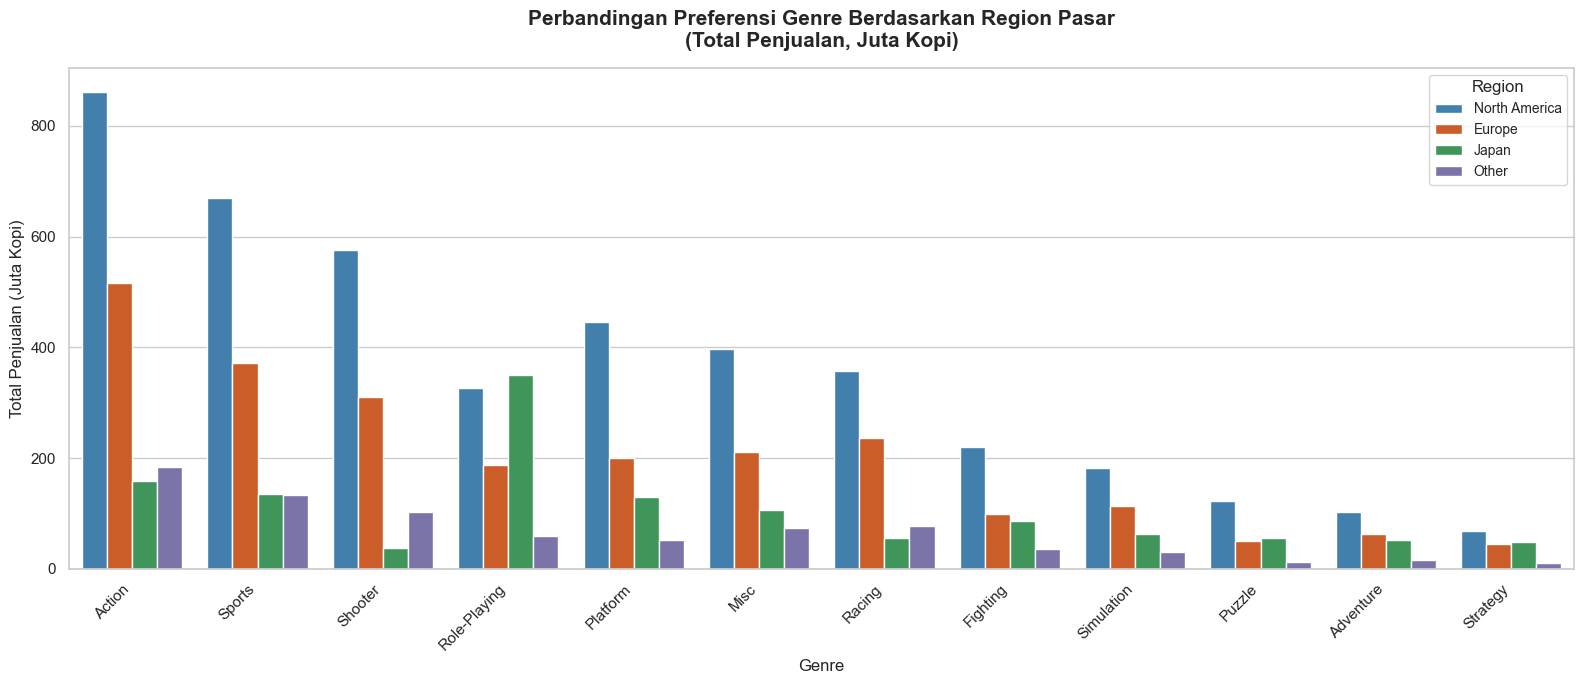

In [11]:
# Visualisasi 3A: Grouped Bar Chart — Genre per Region
reg_melted = regional[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']].reset_index().melt(
    id_vars='Genre', var_name='Region', value_name='Sales'
)
reg_melted['Region'] = reg_melted['Region'].map({
    'NA_Sales': 'North America', 'EU_Sales': 'Europe',
    'JP_Sales': 'Japan', 'Other_Sales': 'Other'
})

fig, ax = plt.subplots(figsize=(16, 7))
sns.barplot(data=reg_melted, x='Genre', y='Sales', hue='Region',
            palette=['#3182bd', '#e6550d', '#31a354', '#756bb1'], ax=ax)

ax.set_title('Perbandingan Preferensi Genre Berdasarkan Region Pasar\n(Total Penjualan, Juta Kopi)', pad=15)
ax.set_xlabel('Genre', fontsize=12)
ax.set_ylabel('Total Penjualan (Juta Kopi)', fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.legend(title='Region', fontsize=10)

plt.tight_layout()
plt.show()

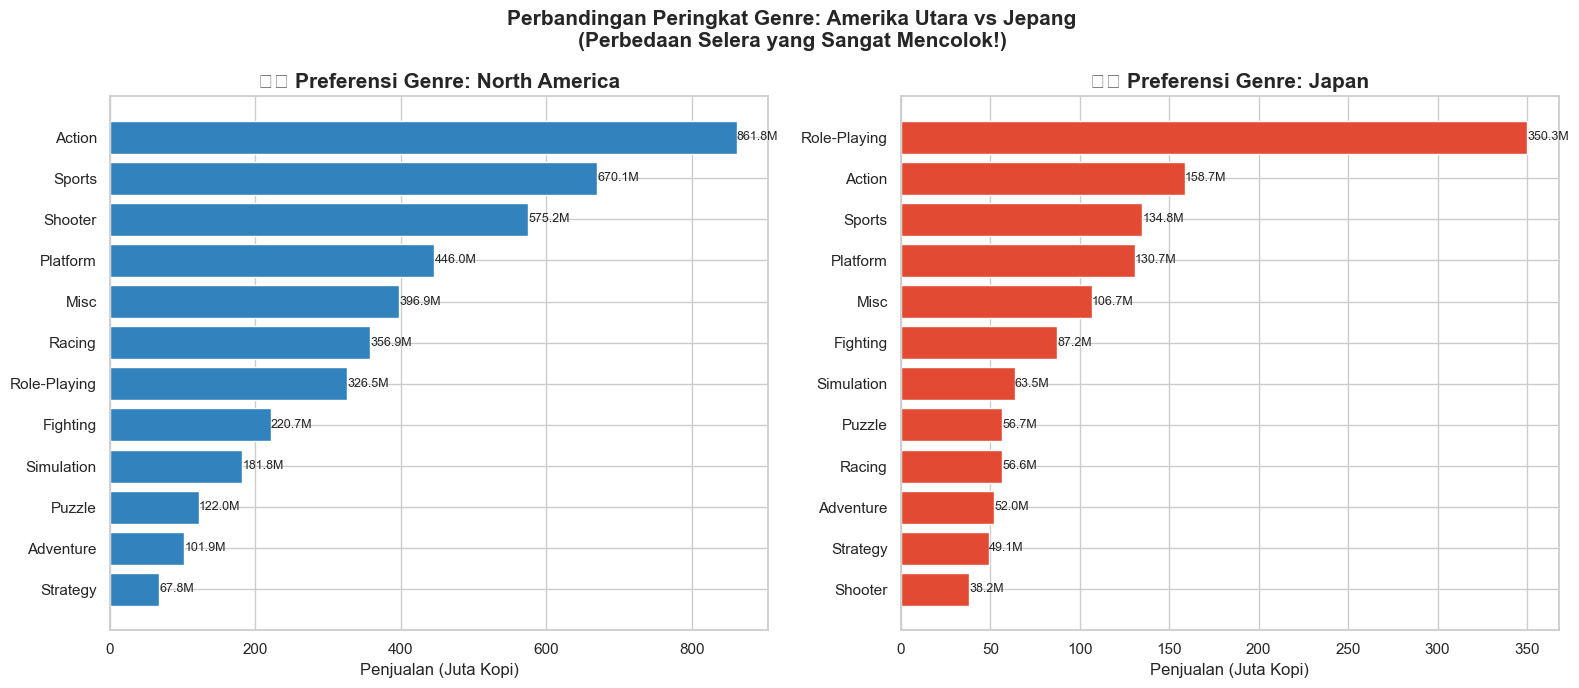


=== GENRE DENGAN PERBEDAAN PERINGKAT TERBESAR (NA vs JP) ===


,Genre,NA_Rank,JP_Rank,Rank_Gap
0,Shooter,3,12,9
1,Role-Playing,7,1,6
2,Racing,6,9,3
3,Fighting,8,6,2
4,Puzzle,10,8,2
5,Simulation,9,7,2
6,Action,1,2,1
7,Sports,2,3,1
8,Strategy,12,11,1
9,Adventure,11,10,1


In [12]:
# Visualisasi 3B: Spotlight NA vs JP — Bar Chart Perbandingan Peringkat Genre
na_rank = regional['NA_Sales'].sort_values(ascending=False).reset_index()
na_rank.columns = ['Genre', 'NA']
na_rank['NA_Rank'] = range(1, len(na_rank)+1)

jp_rank = regional['JP_Sales'].sort_values(ascending=False).reset_index()
jp_rank.columns = ['Genre', 'JP']
jp_rank['JP_Rank'] = range(1, len(jp_rank)+1)

comparison = pd.merge(na_rank, jp_rank, on='Genre')
comparison['Rank_Gap'] = abs(comparison['NA_Rank'] - comparison['JP_Rank'])

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# NA
axes[0].barh(na_rank['Genre'], na_rank['NA'], color='#3182bd', edgecolor='white')
axes[0].invert_yaxis()
axes[0].set_title('🇺🇸 Preferensi Genre: North America', fontweight='bold')
axes[0].set_xlabel('Penjualan (Juta Kopi)')
for i, v in enumerate(na_rank['NA']):
    axes[0].text(v + 0.5, i, f'{v:.1f}M', va='center', fontsize=9)

# JP
axes[1].barh(jp_rank['Genre'], jp_rank['JP'], color='#e34a33', edgecolor='white')
axes[1].invert_yaxis()
axes[1].set_title('🇯🇵 Preferensi Genre: Japan', fontweight='bold')
axes[1].set_xlabel('Penjualan (Juta Kopi)')
for i, v in enumerate(jp_rank['JP']):
    axes[1].text(v + 0.2, i, f'{v:.1f}M', va='center', fontsize=9)

fig.suptitle('Perbandingan Peringkat Genre: Amerika Utara vs Jepang\n(Perbedaan Selera yang Sangat Mencolok!)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n=== GENRE DENGAN PERBEDAAN PERINGKAT TERBESAR (NA vs JP) ===')
display(comparison.sort_values('Rank_Gap', ascending=False)[['Genre','NA_Rank','JP_Rank','Rank_Gap']].reset_index(drop=True))

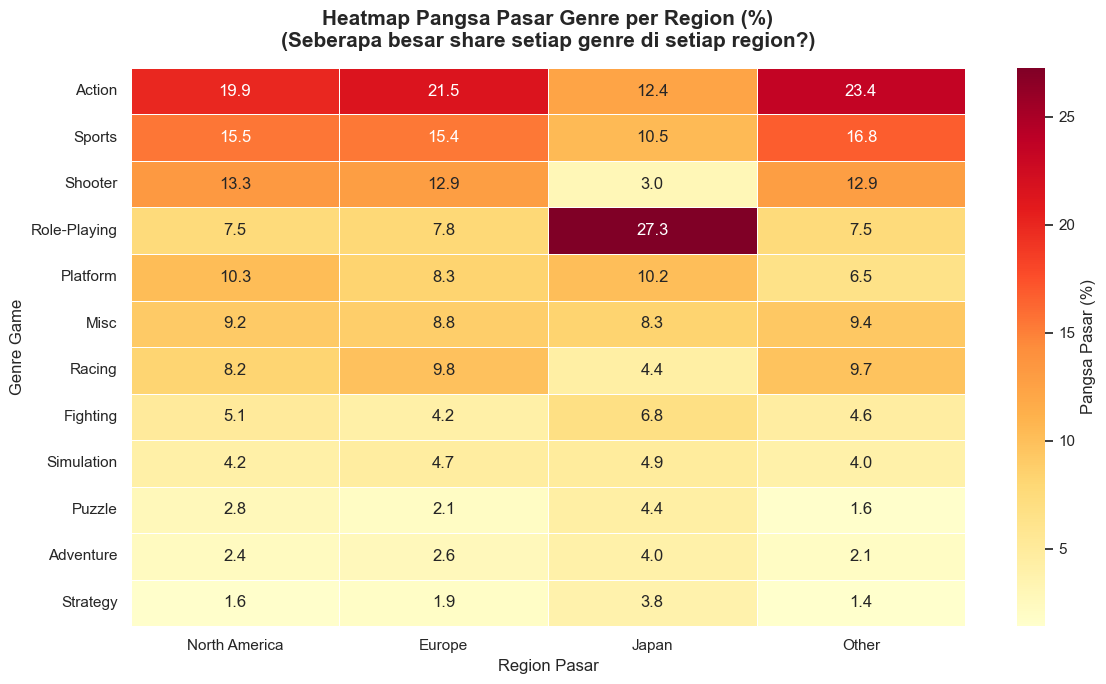

In [13]:
# Visualisasi 3C: Heatmap Penjualan Regional per Genre (Normalized %)
fig, ax = plt.subplots(figsize=(12, 7))

sns.heatmap(regional_pct, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Pangsa Pasar (%)'})

ax.set_title('Heatmap Pangsa Pasar Genre per Region (%)\n(Seberapa besar share setiap genre di setiap region?)', pad=15)
ax.set_xlabel('Region Pasar', fontsize=12)
ax.set_ylabel('Genre Game', fontsize=12)

plt.tight_layout()
plt.show()

### Insight & Temuan — Preferensi Regional

1. **"Anomali Jepang" adalah Nyata dan Signifikan:**  
   Jepang adalah satu-satunya pasar besar di dunia di mana **Role-Playing (RPG)** menjadi genre #1, bukan Action atau Sports. Gap ini sangat ekstrem — RPG di Jepang hampir menyamai seluruh kombinasi genre lain.

2. **Shooter = Kematian di Jepang:**  
   Genre Shooter (FPS/TPS) yang merajai AS — berkat *Call of Duty, Halo, dll.* — hampir tidak trending di pasar Jepang. Ini adalah perbedaan budaya, bukan teknis.

3. **North America & Europe = Saudara Kembar Selera:**  
   Kedua pasar barat ini memiliki pola preferensi yang nyaris identik: Action → Sports → Shooter. Strategi marketing game yang berhasil di AS umumnya bisa langsung diaplikasikan di Eropa.

4. **Sports = Sangat Berbasis Kultur Lokal:**  
   Genre Sports tinggi di NA (NFL, NBA) dan EU (Sepakbola/FIFA), namun jauh lebih rendah di Jepang. Ini mencerminkan budaya olahraga populer yang berbeda.

#### Implikasi Strategis (Lokalisasi Pemasaran):
- **Ekspansi ke Jepang:** Wajib membawa genre RPG/Platform dengan narasi kuat dan desain karakter anime-style
- **Ekspansi ke Barat:** Fokus pada Action kompetitif, Sports berlisensi, atau Shooter sinematik
- **Strategi Hybrid Global:** Action-RPG (seperti *Dark Souls*, *Monster Hunter*) paling aman karena berhasil menembus semua region

---
## Analisis 4: Tren Penjualan Game Global dari Tahun ke Tahun

> Analisis ini menampilkan bagaimana total penjualan video game global berevolusi dari tahun ke tahun — termasuk identifikasi era boom dan dekade terkuat industri game.

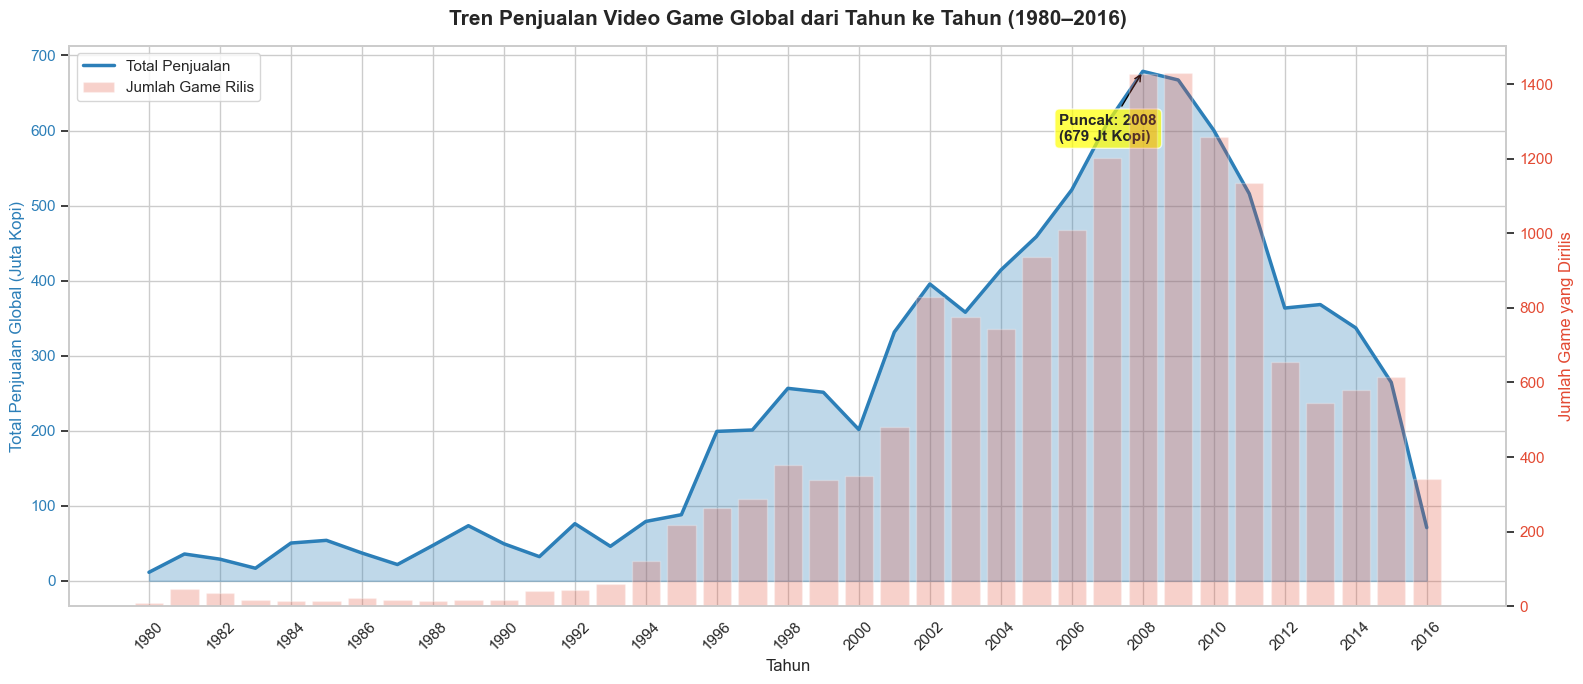

In [14]:
# Tren penjualan per tahun — hapus outlier (>2016 data tipis)
yearly = df_clean[df_clean['Year'] <= 2016].groupby('Year').agg(
    Total_Sales=('Global_Sales', 'sum'),
    Jumlah_Game=('Name', 'count')
).reset_index()

fig, ax1 = plt.subplots(figsize=(16, 7))

ax1.fill_between(yearly['Year'], yearly['Total_Sales'], alpha=0.3, color='#2c7fb8')
ax1.plot(yearly['Year'], yearly['Total_Sales'], color='#2c7fb8', linewidth=2.5, label='Total Penjualan')
ax1.set_ylabel('Total Penjualan Global (Juta Kopi)', color='#2c7fb8', fontsize=12)
ax1.tick_params(axis='y', labelcolor='#2c7fb8')
ax1.set_xlabel('Tahun', fontsize=12)

ax2 = ax1.twinx()
ax2.bar(yearly['Year'], yearly['Jumlah_Game'], alpha=0.25, color='#e34a33', label='Jumlah Game Rilis')
ax2.set_ylabel('Jumlah Game yang Dirilis', color='#e34a33', fontsize=12)
ax2.tick_params(axis='y', labelcolor='#e34a33')
ax2.grid(False)

# Tandai puncak penjualan
peak_year = yearly.loc[yearly['Total_Sales'].idxmax()]
ax1.annotate(f"Puncak: {int(peak_year['Year'])}\n({peak_year['Total_Sales']:.0f} Jt Kopi)",
             xy=(peak_year['Year'], peak_year['Total_Sales']),
             xytext=(-60, -50), textcoords='offset points',
             arrowprops=dict(arrowstyle='->', color='black'),
             fontsize=11, fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.3', fc='yellow', alpha=0.7))

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=11)

ax1.set_title('Tren Penjualan Video Game Global dari Tahun ke Tahun (1980–2016)', pad=15)
ax1.set_xticks(range(int(yearly['Year'].min()), 2017, 2))
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45)

plt.tight_layout()
plt.show()

### Insight — Tren Tahunan

1. **Era Keemasan Industri Game (2006–2010):** Ini adalah lima tahun tersibuk dan terlaris dalam sejarah gaming. Dorongan utamanya: popularitas Wii dan Nintendo DS yang memperkenalkan *casual gaming* ke jutaan orang baru, dikombinasikan dengan boom franchise FPS barat (CoD, Halo).
2. **Puncak Absolut ~2008–2009:** Tahun-tahun di sekitar 2008 mencatat penjualan tertinggi. Ini bukan kebetulan — Wii Sports baru populer, Call of Duty Modern Warfare 2 diluncurkan, DS masih dalam masa kejayaannya.
3. **Penurunan Signifikan Setelah 2010:** Data menunjukkan penurunan volume penjualan fisik secara terus-menerus. Namun ini **bukan tanda kemunduran industri** — ini adalah **pergeseran model distribusi** ke *digital download* dan *mobile gaming* yang tidak terukur dalam dataset ini.

---
## Analisis 5: Genre Terpopuler Sepanjang Masa (Volume & Nilai)

> Analisis ini mengukur popularitas genre dari dua perspektif: **kuantitas jumlah game yang dirilis** vs **kualitas nilai total penjualannya** — untuk melihat apakah genre yang banyak diproduksi juga berbanding lurus dengan profitnya.

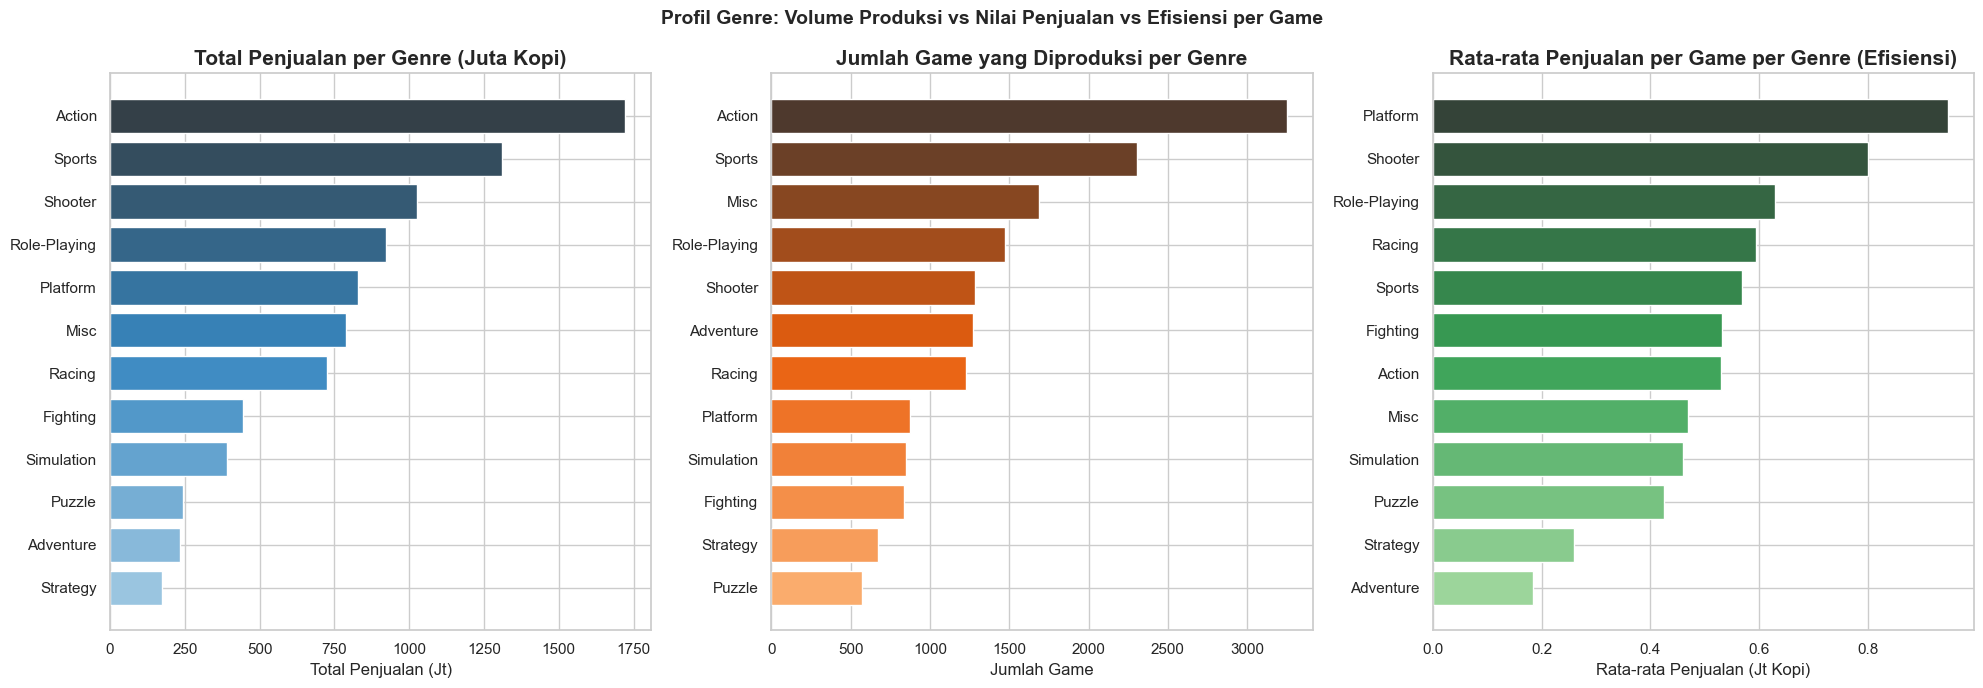

,Genre,Total_Sales,Jumlah_Game,Rata_Sales_per_Game
0,Action,1722.84,3251,0.530
1,Sports,1309.24,2304,0.568
2,Shooter,1026.20,1282,0.800
3,Role-Playing,923.83,1470,0.628
4,Platform,829.13,875,0.948
5,Misc,789.87,1686,0.468
6,Racing,726.76,1225,0.593
7,Fighting,444.05,836,0.531
8,Simulation,389.98,848,0.460
9,Puzzle,242.21,570,0.425


In [15]:
genre_agg = df_clean.groupby('Genre').agg(
    Total_Sales=('Global_Sales', 'sum'),
    Jumlah_Game=('Name', 'count'),
    Rata_Sales_per_Game=('Global_Sales', 'mean')
).sort_values('Total_Sales', ascending=False).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

# Panel 1: Total Sales
bars = axes[0].barh(genre_agg['Genre'][::-1], genre_agg['Total_Sales'][::-1], color=sns.color_palette('Blues_d', len(genre_agg)))
axes[0].set_title('Total Penjualan per Genre (Juta Kopi)', fontweight='bold')
axes[0].set_xlabel('Total Penjualan (Jt)')

# Panel 2: Jumlah Game
genre_vol = genre_agg.sort_values('Jumlah_Game', ascending=False)
axes[1].barh(genre_vol['Genre'][::-1], genre_vol['Jumlah_Game'][::-1], color=sns.color_palette('Oranges_d', len(genre_agg)))
axes[1].set_title('Jumlah Game yang Diproduksi per Genre', fontweight='bold')
axes[1].set_xlabel('Jumlah Game')

# Panel 3: Rata-rata Sales per Game
genre_eff = genre_agg.sort_values('Rata_Sales_per_Game', ascending=False)
axes[2].barh(genre_eff['Genre'][::-1], genre_eff['Rata_Sales_per_Game'][::-1], color=sns.color_palette('Greens_d', len(genre_agg)))
axes[2].set_title('Rata-rata Penjualan per Game per Genre (Efisiensi)', fontweight='bold')
axes[2].set_xlabel('Rata-rata Penjualan (Jt Kopi)')

fig.suptitle('Profil Genre: Volume Produksi vs Nilai Penjualan vs Efisiensi per Game', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

display(genre_agg.round(3))

### Insight — Profil Genre

1. **Genre Action = Juara Volume Sekaligus Nilai Total:**  Genre Action muncul sebagai raja dari kedua sisi — ia paling banyak diproduksi **dan** memiliki total penjualan tertinggi. Ini menunjukkan dominasinya yang menyeluruh.

2. **Sports: Diproduksi Sedikit, Hasil Besar (Efisiensi Tinggi):** Genre Platform dan Sports memiliki **rata-rata penjualan per game yang sangat tinggi**. Artinya, game-game di genre ini rata-rata adalah *blockbuster* — sedikit judul tapi masing-masing sangat laris. Ini menunjukkan adanya franchise mega-hits (Mario, FIFA, Wii Sports) yang mendorong rata-rata ke atas.

3. **Puzzle & Strategy: Diproduksi Banyak, Hasil Tipis:** Genre ini mencetak banyak game, namun kontribusi penjualannya rendah per game. Ini adalah area pasar yang *oversupplied* dan mungkin bernilai rendah secara komersial.

4. **Misc (Miscellaneous): Menarik Diamati:** Kategori ini muncul sebagai penampung game yang tidak bisa dikategorikan. Penjualannya cukup signifikan karena menampung fenomena seperti *Wii Sports, Just Dance*, dan *Brain Age* yang sangat populer namun sulit dikategorikan ke genre "standar".

---
## Rangkuman Hasil Analisis

| Topik | Temuan Kunci |
|-------|-------------|
| **Platform** | PS2 = Raja Total Sales; PC = Platform tertahan hidup terlama; Handheld (DS, GB) setara konsol rumah |
| **Publisher** | Setiap publisher raksasa sangat spesialis di genrenya; Take-Two paling terpusat (57% dari Action/GTA) |
| **Regional** | NA & EU identik seleranya; Jepang adalah anomali (RPG #1, Shooter hampir nol) |
| **Tren Tahunan** | Puncak industri: 2006–2010; Penurunan akibat migrasi ke digital, bukan kemunduran |
| **Genre Profil** | Action = volume + nilai; Platform/Sports = efisiensi tinggi per game; Puzzle = oversupplied |

---
### Stack Teknologi
- **Bahasa:** Python 3  
- **Library:** `pandas`, `matplotlib`, `seaborn`, `numpy`  
- **Dataset:** [Video Game Sales (Kaggle)](https://www.kaggle.com/datasets/gregorut/videogamesales)  

*(Portofolio Data Analysis — 2026)*